# TFLite Model Testing

Evaluates the `.tflite` model that ships in the Android app on the held-out **test split** at `data/preprocessed/test`.

Pre/post-processing mirrors `mobile-app/.../ObjectDetector.kt` exactly:
- Letterbox to 640×640 with grey (114) padding
- NHWC float32, values in [0, 1]
- Output `[1, 300, 6]` post-NMS — `[x1, y1, x2, y2, conf, class_id]`
- Coord-scale auto-detect (newer Ultralytics exports emit normalised [0,1]; older emit absolute pixels)

**Currently deployed:** `yolo26s.tflite` only. The other architectures (rtdetr_l, rfdetr_nano) have not been re-trained / re-exported as TFLite yet, so they're excluded.

**Metrics reported:**
- mAP50 and per-class AP50
- Mean IoU of true-positive matches
- Macro-averaged Precision / Recall / F1 at the per-class best-F1 threshold
- Inference time (ms/image) and FPS on CPU
- **Glasses ↔ Sunglasses confusion matrix** — direct evidence for the mentor discussion on improving that distinction

In [2]:
import os, time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

try:
    from tflite_runtime.interpreter import Interpreter
except ImportError:
    import tensorflow as tf
    Interpreter = tf.lite.Interpreter

ASSETS_DIR   = Path('../../mobile-app/app/src/main/assets')
TEST_IMG_DIR = Path('../data/preprocessed/test/images')
TEST_LBL_DIR = Path('../data/preprocessed/test/labels')

# Class order — must match data.yaml AND ObjectDetector.kt LABEL_TO_CLASS_INDEX
CLASSES    = ['Keys', 'Sunglasses', 'Wallet', 'glasses']
NC         = len(CLASSES)
IOU_THRESH = 0.50

for p in [ASSETS_DIR, TEST_IMG_DIR, TEST_LBL_DIR]:
    print(f"{'OK' if p.exists() else 'MISSING'}: {p.resolve()}")

imgs = sorted(TEST_IMG_DIR.glob('*.jpg')) + sorted(TEST_IMG_DIR.glob('*.png'))
print(f'\n{len(imgs)} test images found')

OK: C:\Users\Bradley\git\FYP\mobile-app\app\src\main\assets
OK: C:\Users\Bradley\git\FYP\ml-training\data\preprocessed\test\images
OK: C:\Users\Bradley\git\FYP\ml-training\data\preprocessed\test\labels

376 test images found


## Pre/post-processing — mirrors ObjectDetector.kt

In [3]:
def letterbox(img, target):
    """Aspect-preserving resize to target×target with grey-114 padding.
    Mirrors ObjectDetector.kt:letterbox() exactly."""
    w, h    = img.size
    scale   = min(target / w, target / h)
    nw, nh  = int(w * scale), int(h * scale)
    resized = img.resize((nw, nh), Image.BILINEAR)
    canvas  = Image.new('RGB', (target, target), (114, 114, 114))
    pl, pt  = (target - nw) // 2, (target - nh) // 2
    canvas.paste(resized, (pl, pt))
    return canvas, scale, pl, pt

def to_nhwc(img):
    """PIL RGB → NHWC float32 [0, 1] with batch dim. Mirrors fillInputBuffer()."""
    arr = np.array(img, dtype=np.float32) / 255.0
    return arr[np.newaxis]   # [1, H, W, 3]

def iou_cxcywh(b1, b2):
    ax1, ay1 = b1[0]-b1[2]/2, b1[1]-b1[3]/2
    ax2, ay2 = b1[0]+b1[2]/2, b1[1]+b1[3]/2
    bx1, by1 = b2[0]-b2[2]/2, b2[1]-b2[3]/2
    bx2, by2 = b2[0]+b2[2]/2, b2[1]+b2[3]/2
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    union = b1[2]*b1[3] + b2[2]*b2[3] - inter
    return inter / union if union > 0 else 0.0

def load_gt(label_path):
    """YOLO-format label file → list of [cls, cx, cy, w, h] (normalised)."""
    p = Path(label_path)
    if not p.exists():
        return []
    out = []
    for line in p.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) == 5:
            out.append([int(parts[0])] + [float(v) for v in parts[1:]])
    return out

print('Helpers loaded.')

Helpers loaded.


In [4]:
class TFLiteYoloRunner:
    """
    yolo26s.tflite (Ultralytics export with NMS, 4 classes)
    Input : [1, 640, 640, 3]  RGB [0,1]  letterboxed
    Output: [1, 300, 6]       x1 y1 x2 y2 conf class_id  (post-NMS)

    Coord scale: newer exports emit [0,1] normalised; older emit absolute pixels in 640 space.
    Auto-detected from the first confident detection — same logic as ObjectDetector.kt:232.
    """
    SIZE = 640
    CONF = 0.25   # low so we capture the full PR curve (Android uses 0.30)

    def __init__(self, path):
        self.interp = Interpreter(model_path=str(path), num_threads=4)
        self.interp.allocate_tensors()
        self.inp_idx = self.interp.get_input_details()[0]['index']
        self.out_idx = self.interp.get_output_details()[0]['index']
        in_shape  = self.interp.get_input_details()[0]['shape']
        out_shape = self.interp.get_output_details()[0]['shape']
        print(f'  input shape:  {list(in_shape)}')
        print(f'  output shape: {list(out_shape)}')

    def run(self, img_path):
        """Returns (detections, inference_ms).
        detections: list of [cls, conf, cx_norm, cy_norm, w_norm, h_norm] in original-image coords.
        """
        with Image.open(img_path) as _f:
            img = _f.convert('RGB')
        W, H = img.size
        lb, scale, pl, pt = letterbox(img, self.SIZE)
        x = to_nhwc(lb)

        self.interp.set_tensor(self.inp_idx, x)
        t0 = time.perf_counter()
        self.interp.invoke()
        ms = (time.perf_counter() - t0) * 1000
        raw = self.interp.get_tensor(self.out_idx)[0]   # [300, 6]

        # Coord-scale auto-detect (mirrors ObjectDetector.kt line 232–235):
        # if x2 of the first confident detection ≤ 2.0 → output is normalised, multiply by SIZE.
        first_conf = next((d for d in raw if d[4] > self.CONF), None)
        coord_scale = float(self.SIZE) if (first_conf is not None and first_conf[2] <= 2.0) else 1.0

        cW, cH = int(W * scale), int(H * scale)
        dets = []
        for det in raw:
            conf   = float(det[4])
            cls_id = int(det[5])
            if conf < self.CONF:
                continue
            x1 = det[0] * coord_scale; y1 = det[1] * coord_scale
            x2 = det[2] * coord_scale; y2 = det[3] * coord_scale
            cx = (((x1 + x2) / 2) - pl) / cW
            cy = (((y1 + y2) / 2) - pt) / cH
            w  = (x2 - x1) / cW
            h  = (y2 - y1) / cH
            dets.append([cls_id, conf,
                         float(np.clip(cx, 0, 1)), float(np.clip(cy, 0, 1)),
                         float(np.clip(w,  0, 1)), float(np.clip(h,  0, 1))])
        return dets, ms

print('TFLiteYoloRunner defined.')

TFLiteYoloRunner defined.


## Evaluation

In [5]:
def evaluate(runner, images):
    """Run runner on all images. Returns:
      per_class_preds: {cls: [(conf, is_tp), ...]}
      per_class_gt:    {cls: total GT count}
      mean_ms:         average inference time (ms)
      tp_ious:         IoU values of TP matches
      confusion:       NC×NC matrix of GT-class → predicted-class for matched detections
                       (matched = pred IoU >= IOU_THRESH with a GT of any class)
    """
    per_class_preds = {c: [] for c in range(NC)}
    per_class_gt    = {c: 0  for c in range(NC)}
    tp_ious = []
    total_ms = 0.0
    confusion = np.zeros((NC, NC), dtype=int)   # [gt][pred]

    for img_path in images:
        gt = load_gt(TEST_LBL_DIR / (img_path.stem + '.txt'))
        for box in gt:
            per_class_gt[box[0]] += 1

        preds, ms = runner.run(img_path)
        total_ms += ms

        # Same-class greedy match for AP/IoU
        matched = set()
        for pred in sorted(preds, key=lambda d: d[1], reverse=True):
            cls_id, conf, cx, cy, w, h = pred
            best_iou, best_j = 0.0, -1
            for j, gt_box in enumerate(gt):
                if gt_box[0] != cls_id or j in matched:
                    continue
                v = iou_cxcywh((cx, cy, w, h), tuple(gt_box[1:]))
                if v > best_iou:
                    best_iou, best_j = v, j
            is_tp = best_iou >= IOU_THRESH
            per_class_preds[cls_id].append((conf, is_tp))
            if is_tp:
                matched.add(best_j)
                tp_ious.append(best_iou)

        # Cross-class confusion: each pred is matched to its highest-IoU GT regardless of class
        gt_taken = set()
        for pred in sorted(preds, key=lambda d: d[1], reverse=True):
            pred_cls, _, cx, cy, w, h = pred
            best_iou, best_j, best_gt_cls = 0.0, -1, -1
            for j, gt_box in enumerate(gt):
                if j in gt_taken:
                    continue
                v = iou_cxcywh((cx, cy, w, h), tuple(gt_box[1:]))
                if v > best_iou:
                    best_iou, best_j, best_gt_cls = v, j, gt_box[0]
            if best_iou >= IOU_THRESH:
                confusion[best_gt_cls, pred_cls] += 1
                gt_taken.add(best_j)

    return per_class_preds, per_class_gt, total_ms / max(len(images), 1), tp_ious, confusion


def compute_ap(preds, n_gt):
    """AP at IOU_THRESH using 11-point VOC interpolation."""
    if n_gt == 0 or not preds:
        return 0.0
    preds = sorted(preds, key=lambda x: x[0], reverse=True)
    tp_cum = fp_cum = 0
    prec, rec = [], []
    for _, is_tp in preds:
        if is_tp: tp_cum += 1
        else:     fp_cum += 1
        prec.append(tp_cum / (tp_cum + fp_cum))
        rec.append(tp_cum / n_gt)
    ap = 0.0
    for t in np.linspace(0, 1, 11):
        ps = [p for p, r in zip(prec, rec) if r >= t]
        ap += max(ps) if ps else 0.0
    return ap / 11


def compute_prf_at_best_f1(per_class_preds, per_class_gt):
    """Macro-avg P/R/F1 at the per-class best-F1 confidence threshold."""
    precisions, recalls, f1s = [], [], []
    for c in range(NC):
        n_gt  = per_class_gt[c]
        preds = per_class_preds[c]
        if n_gt == 0 or not preds:
            continue
        preds_sorted = sorted(preds, key=lambda x: x[0], reverse=True)
        best_f1 = best_p = best_r = 0.0
        tp_cum = fp_cum = 0
        for _, is_tp in preds_sorted:
            if is_tp: tp_cum += 1
            else:     fp_cum += 1
            p  = tp_cum / (tp_cum + fp_cum)
            r  = tp_cum / n_gt
            f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
            if f1 > best_f1:
                best_f1, best_p, best_r = f1, p, r
        precisions.append(best_p); recalls.append(best_r); f1s.append(best_f1)
    if not f1s:
        return 0.0, 0.0, 0.0
    return float(np.mean(precisions)), float(np.mean(recalls)), float(np.mean(f1s))

print('Evaluation functions defined.')

Evaluation functions defined.


In [6]:
MODEL_PATH = ASSETS_DIR / 'yolo26s.tflite'
assert MODEL_PATH.exists(), f'Missing model: {MODEL_PATH}'

size_mb = MODEL_PATH.stat().st_size / 1e6
print('=' * 60)
print(f'  yolo26s.tflite  ({size_mb:.1f} MB)')
print('=' * 60)

runner = TFLiteYoloRunner(MODEL_PATH)
per_class_preds, per_class_gt, mean_ms, tp_ious, confusion = evaluate(runner, imgs)

aps = {CLASSES[c]: compute_ap(per_class_preds[c], per_class_gt[c]) for c in range(NC)}
prec, rec, f1 = compute_prf_at_best_f1(per_class_preds, per_class_gt)

row = {
    'Model':          'yolo26s.tflite',
    'mAP50':          round(float(np.mean(list(aps.values()))), 4),
    'Mean IoU (TP)':  round(float(np.mean(tp_ious)) if tp_ious else 0.0, 4),
    'Precision':      round(prec, 4),
    'Recall':         round(rec,  4),
    'F1':             round(f1,   4),
    'Inference (ms)': round(mean_ms, 1),
    'FPS':            round(1000 / mean_ms, 1) if mean_ms > 0 else 0.0,
    'Size (MB)':      round(size_mb, 1),
}
for cls, ap in aps.items():
    row[f'AP50 {cls}'] = round(ap, 4)

df = pd.DataFrame([row]).set_index('Model')
print()
print(df.to_string())

  yolo26s.tflite  (38.2 MB)
  input shape:  [np.int32(1), np.int32(640), np.int32(640), np.int32(3)]
  output shape: [np.int32(1), np.int32(300), np.int32(6)]


c:\Users\Bradley\miniconda3\envs\fyp\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



                 mAP50  Mean IoU (TP)  Precision  Recall     F1  Inference (ms)   FPS  Size (MB)  AP50 Keys  AP50 Sunglasses  AP50 Wallet  AP50 glasses
Model                                                                                                                                                  
yolo26s.tflite  0.9003         0.8924       0.94  0.9263  0.933            45.8  21.8       38.2     0.9041           0.9048       0.8984        0.8939


## Glasses ↔ Sunglasses Confusion

Direct evidence for the mentor discussion. Each row is the **ground-truth** class; each column is what the model **predicted**. Diagonal = correct, off-diagonal = swapped.

Full confusion matrix (matched detections only, IoU ≥ 0.50):
               pred Keys  pred Sunglasses  pred Wallet  pred glasses
GT Keys              109                0            0             0
GT Sunglasses          1               80            0             4
GT Wallet              0                0           98             0
GT glasses             0                2            0           105

Sunglasses ↔ glasses sub-matrix:
               pred Sunglasses  pred glasses
GT Sunglasses               80             4
GT glasses                   2           105

  GT Sunglasses : 80 correct, 4 mis-classed as glasses (4.7% swap rate, 94.1% correct of 85 matched)

  GT glasses    : 105 correct, 2 mis-classed as Sunglasses (1.9% swap rate, 98.1% correct of 107 matched)


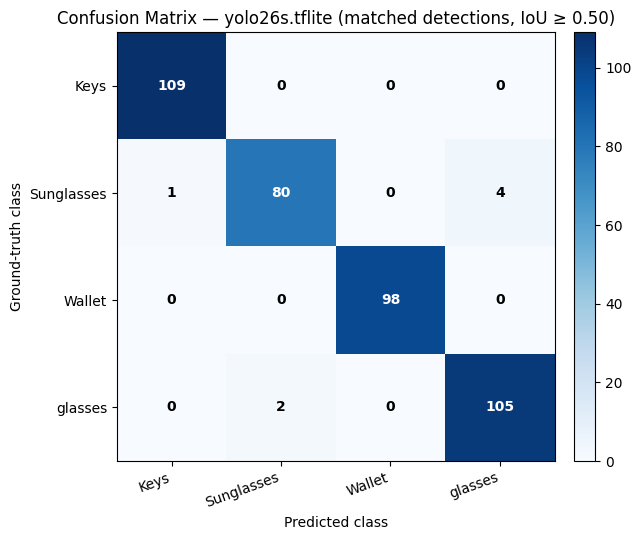


Saved: runs/tflite_test/confusion_matrix.png


In [7]:
# Full 4×4 confusion matrix
cm_df = pd.DataFrame(confusion, index=[f'GT {c}' for c in CLASSES],
                                  columns=[f'pred {c}' for c in CLASSES])
print('Full confusion matrix (matched detections only, IoU ≥ 0.50):')
print(cm_df.to_string())

# Focus on glasses ↔ sunglasses
i_sun, i_gla = CLASSES.index('Sunglasses'), CLASSES.index('glasses')
sub = confusion[np.ix_([i_sun, i_gla], [i_sun, i_gla])]
sub_df = pd.DataFrame(sub, index=['GT Sunglasses', 'GT glasses'],
                            columns=['pred Sunglasses', 'pred glasses'])
print('\nSunglasses ↔ glasses sub-matrix:')
print(sub_df.to_string())

# Per-class swap rates
for gt_idx, gt_name, other_idx, other_name in [
    (i_sun, 'Sunglasses', i_gla, 'glasses'),
    (i_gla, 'glasses',    i_sun, 'Sunglasses'),
]:
    correct = confusion[gt_idx, gt_idx]
    swapped = confusion[gt_idx, other_idx]
    total   = confusion[gt_idx].sum()
    if total > 0:
        print(f'\n  GT {gt_name:<11s}: {correct} correct, {swapped} mis-classed as {other_name} '
              f'({swapped/total*100:.1f}% swap rate, {correct/total*100:.1f}% correct of {total} matched)')

# Visual heatmap
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(confusion, cmap='Blues', aspect='auto')
ax.set_xticks(range(NC)); ax.set_xticklabels(CLASSES, rotation=20, ha='right')
ax.set_yticks(range(NC)); ax.set_yticklabels(CLASSES)
ax.set_xlabel('Predicted class'); ax.set_ylabel('Ground-truth class')
ax.set_title('Confusion Matrix — yolo26s.tflite (matched detections, IoU ≥ 0.50)')
for i in range(NC):
    for j in range(NC):
        v = confusion[i, j]
        ax.text(j, i, str(v), ha='center', va='center',
                color='white' if v > confusion.max() / 2 else 'black', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
os.makedirs('runs/tflite_test', exist_ok=True)
plt.savefig('runs/tflite_test/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: runs/tflite_test/confusion_matrix.png')

## Charts

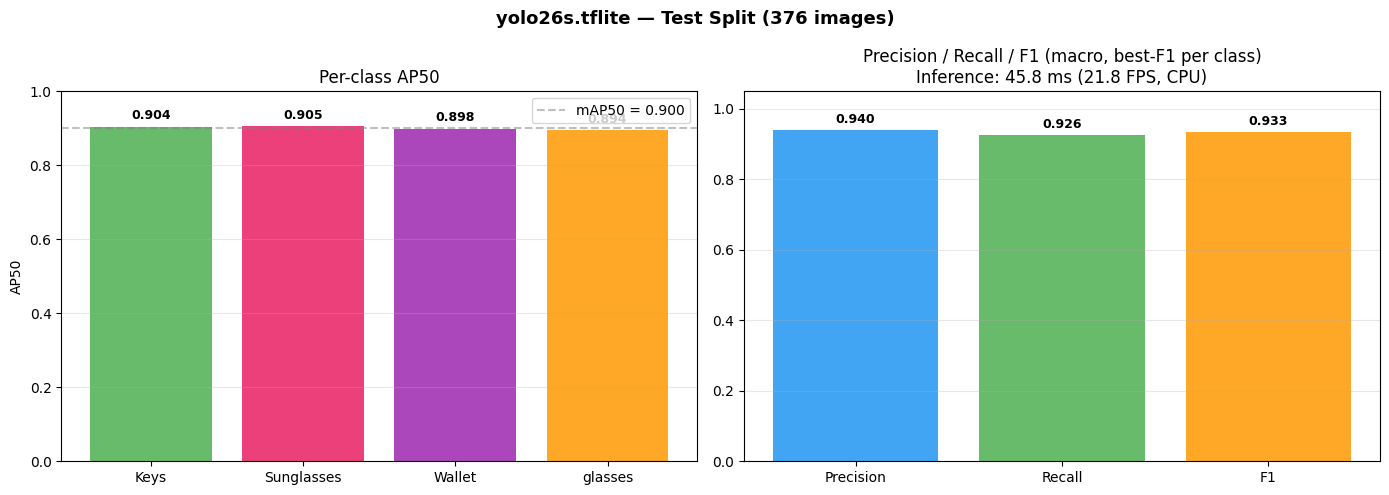

Saved: runs/tflite_test/comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'yolo26s.tflite — Test Split ({len(imgs)} images)',
             fontsize=13, fontweight='bold')

# Chart 1: Per-class AP50
ax = axes[0]
cls_colors = ['#4CAF50', '#E91E63', '#9C27B0', '#FF9800']
vals = [aps[c] for c in CLASSES]
bars = ax.bar(CLASSES, vals, color=cls_colors, alpha=0.85)
ax.set_ylim(0, 1.0)
ax.axhline(row['mAP50'], color='gray', linestyle='--', alpha=0.5,
           label=f"mAP50 = {row['mAP50']:.3f}")
ax.set_title('Per-class AP50'); ax.set_ylabel('AP50'); ax.legend()
ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}',
            ha='center', fontsize=9, fontweight='bold')

# Chart 2: Precision / Recall / F1
ax = axes[1]
metrics = ['Precision', 'Recall', 'F1']
vals    = [row[m] for m in metrics]
bars    = ax.bar(metrics, vals, color=['#2196F3', '#4CAF50', '#FF9800'], alpha=0.85)
ax.set_ylim(0, 1.05)
ax.set_title(f"Precision / Recall / F1 (macro, best-F1 per class)\n"
             f"Inference: {row['Inference (ms)']:.1f} ms ({row['FPS']:.1f} FPS, CPU)")
ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('runs/tflite_test/comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: runs/tflite_test/comparison.png')

## Visual spot-check

Ground truth (dashed) vs model predictions (solid). Targeted at images containing **glasses** or **sunglasses** GT boxes — the classes the mentor discussion is focused on.

Selected 6 test images containing glasses/sunglasses


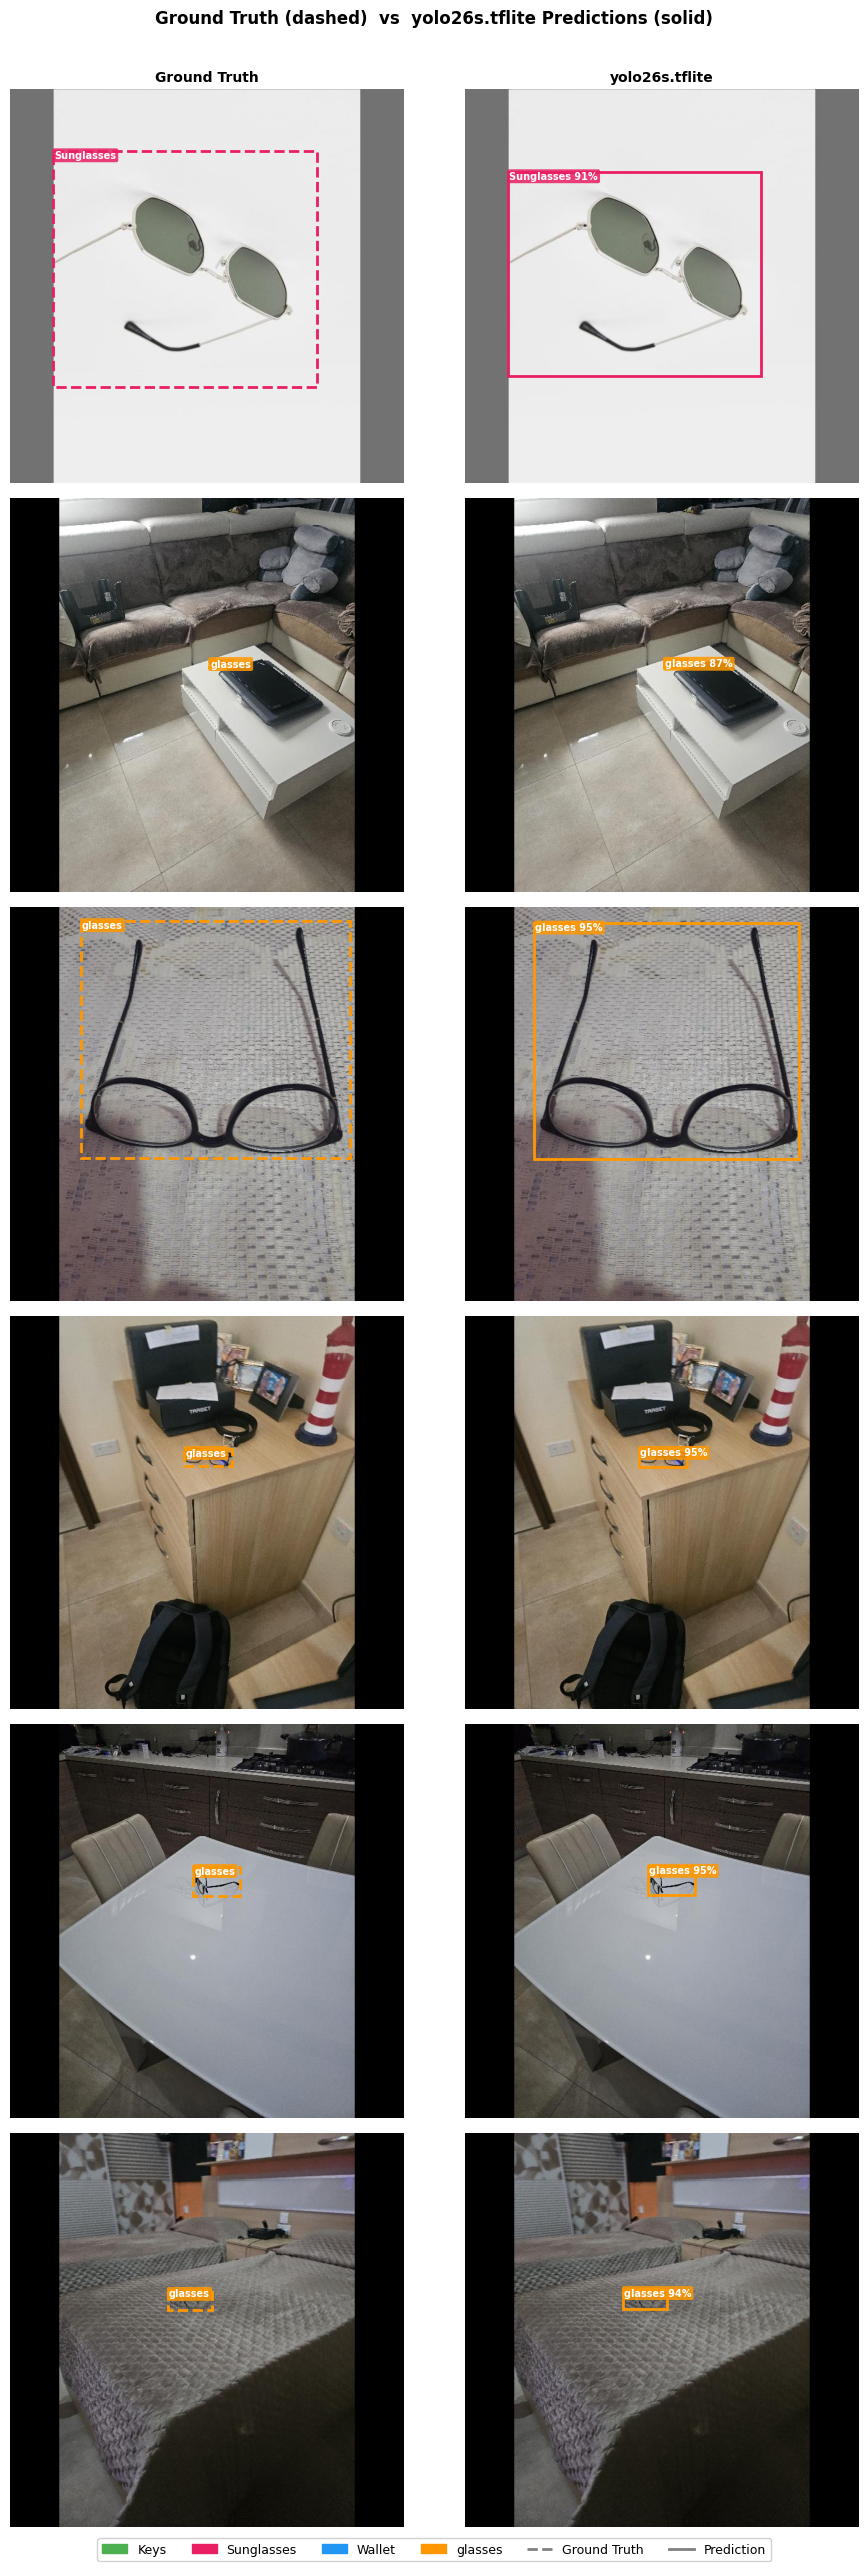

Saved: runs/tflite_test/visual_samples.png


In [9]:
import random
from matplotlib.lines import Line2D
from matplotlib import patches as mpatches

random.seed(42)
N_SAMPLES = 6
CONF_VIS  = 0.30   # matches Android CONFIDENCE_THRESHOLD
CLS_COLORS = ['#4CAF50', '#E91E63', '#2196F3', '#FF9800']  # Keys, Sun, Wallet, glasses

i_sun, i_gla = CLASSES.index('Sunglasses'), CLASSES.index('glasses')
candidates = [
    p for p in imgs
    if any(b[0] in (i_sun, i_gla) for b in load_gt(TEST_LBL_DIR / (p.stem + '.txt')))
]
samples = random.sample(candidates, min(N_SAMPLES, len(candidates)))
print(f'Selected {len(samples)} test images containing glasses/sunglasses')

preds_per_img = {p: [d for d in runner.run(p)[0] if d[1] >= CONF_VIS] for p in samples}

def draw_boxes(ax, img, boxes, gt=False):
    ax.imshow(img)
    W, H = img.size
    for box in boxes:
        if gt:
            cls_id, cx, cy, w, h = box
            label_txt = CLASSES[cls_id]
        else:
            cls_id, conf, cx, cy, w, h = box
            label_txt = f'{CLASSES[cls_id]} {conf*100:.0f}%'
        x1 = (cx - w/2) * W; y1 = (cy - h/2) * H
        bw = w * W;          bh = h * H
        color = CLS_COLORS[cls_id % len(CLS_COLORS)]
        rect = plt.Rectangle((x1, y1), bw, bh, linewidth=2, edgecolor=color,
                             facecolor='none', linestyle='--' if gt else '-')
        ax.add_patch(rect)
        ax.text(x1 + 2, y1 + 12, label_txt, color='white', fontsize=7, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.85, edgecolor='none'))
    ax.axis('off')

n_rows = len(samples)
fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4.2 * n_rows), squeeze=False)
fig.suptitle('Ground Truth (dashed)  vs  yolo26s.tflite Predictions (solid)',
             fontsize=12, fontweight='bold', y=1.005)

for row_i, img_path in enumerate(samples):
    img = Image.open(img_path).convert('RGB')
    gt  = load_gt(TEST_LBL_DIR / (img_path.stem + '.txt'))
    draw_boxes(axes[row_i][0], img, gt, gt=True)
    draw_boxes(axes[row_i][1], img, preds_per_img[img_path], gt=False)
    if row_i == 0:
        axes[row_i][0].set_title('Ground Truth', fontsize=10, fontweight='bold')
        axes[row_i][1].set_title('yolo26s.tflite', fontsize=10, fontweight='bold')

legend_handles = [mpatches.Patch(color=CLS_COLORS[i], label=CLASSES[i]) for i in range(NC)] + [
    Line2D([0], [0], color='gray', lw=2, linestyle='--', label='Ground Truth'),
    Line2D([0], [0], color='gray', lw=2, linestyle='-',  label='Prediction'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=NC + 2,
           fontsize=9, bbox_to_anchor=(0.5, -0.01), framealpha=0.9)

plt.tight_layout()
plt.savefig('runs/tflite_test/visual_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: runs/tflite_test/visual_samples.png')

In [10]:
# Persist results
df.reset_index().to_json('runs/tflite_test/results.json', orient='records', indent=2)
cm_df.to_csv('runs/tflite_test/confusion_matrix.csv')
print('Saved: runs/tflite_test/results.json')
print('Saved: runs/tflite_test/confusion_matrix.csv')

Saved: runs/tflite_test/results.json
Saved: runs/tflite_test/confusion_matrix.csv
